# Densidad de probabilidad de la ecuación de Klein-Gordon 🌸🌸🎀🎀

## Densidad de energía completa - KG

In [ ]:
pip install scipy

In [ ]:
# -- Modificación por el usuario --
nr = input("Ingrese el valor de nr: ")
l = input("Ingrese el valor de l: ")
m_quantum = input("Ingrese el valor de m_quantum: ")

nr = float(nr)
l = int(l)
m_quantum = int(m_quantum)

Ingrese el valor de nr: 1
Ingrese el valor de l: 1
Ingrese el valor de m_quantum: 1


Ingrese el valor de nr: 2
Ingrese el valor de l: 1
Ingrese el valor de m_quantum: 0
Ingrese el valor de Z_atom: 1
Ingrese el valor del numero cuantico principal n: 3


/tmp/ipykernel_604/244488434.py:66: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  Y_lm = sph_harm(m_quantum, l, phi, theta)


----------------------------------------------------------------
Resultados de parámetros de la ecuación de Dirac
Estado evaluado: n = 3, j = 0.5, kappa = -1
E_Dirac (Total)  = 510997.4382 eV  (Cercana a m_e c^2)
E_Dirac (Ligada) = -1.5118 eV (Comparable con el offset de Bohr)
----------------------------------------------------------------
Resultados de parametros de la ecuación de KG
Estado evaluado: nr = 2.0, l = 1, m_quantum = 0
Energía de ligadura de Klein Gordon = 510997.78932365257 eV


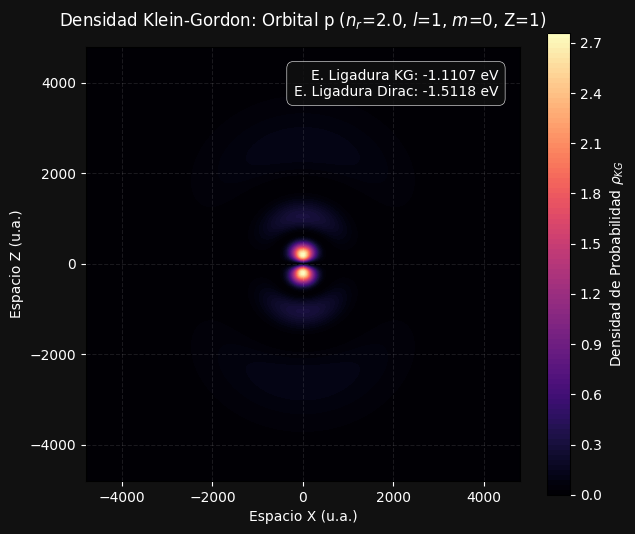

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm, eval_genlaguerre

# ========== Configuración del sistema ================
# Orbital equivalente al 1s (Estado fundamental)
nr = 0
l = 1
m_quantum = 0

# Constantes físicas en unidades atómicas/naturales
Z_atom = 70          # <--- CAMBIAR DE 1 A 5
alpha = 1 / 137.036
m_e = 0.51099895e6
m = 1.0
m_eV = 0.51099895e6

nr = input("Ingrese el valor de nr: ")
l = input("Ingrese el valor de l: ")
m_quantum = input("Ingrese el valor de m_quantum: ")
Z_atom = input("Ingrese el valor de Z_atom: ")

Z_atom = int(Z_atom)
nr = float(nr)
l = int(l)
m_quantum = int(m_quantum)

# =========== Ecuacion de KLEIN-GORDON ================ según el usuario
def calcular_propiedades_kg(nr, l):
    # Parámetro lambda definido por el usuario
    termino_raiz = np.sqrt((l + 0.5)**2 - (Z_atom * alpha)**2)
    lambda_param = -0.5 + termino_raiz

    # Determinación de la Energía Relativista E
    # n_efectivo = nr + lambda + 0.5
    n_efectivo = nr + termino_raiz
    E = m * (1 + (Z_atom * alpha)**2 / (n_efectivo)**2)**(-0.5)

    # Parámetro gamma definido por el usuario
    gamma = 2 * np.sqrt(m**2 - E**2)

    return lambda_param, gamma, E

# Se obtienen los parámetros numéricos según los números cuánticos elegidos
lambda_param, gamma, E = calcular_propiedades_kg(nr, l)

def funcion_radial_kg(r):
    x = gamma * r
    orden_laguerre = 2 * lambda_param + 1

    # Evaluamos el polinomio generalizado de Laguerre con orden fraccionario
    polinomio = eval_genlaguerre(nr, orden_laguerre, x)

    # Componente radial completo R_{nr, l}(r)
    R = (x**lambda_param) * np.exp(-x / 2) * polinomio
    return R

    R = funcion_radial_kg(r)

def calcular_densidad_total(r, theta, phi):
    # 1. Componente Radial al cuadrado
    R_cuadrado = np.abs(funcion_radial_kg(r))**2

    # 2. Componente Angular al cuadrado (Armónicos esféricos)
    # Nota: SciPy requiere los ángulos en orden (m, l, azimutal, polar)
    Y_lm = sph_harm(m_quantum, l, phi, theta)
    Y_cuadrado = np.abs(Y_lm)**2

    # 3. Factor relativista de la densidad de Klein-Gordon
    factor_relativista = E + (Z_atom * alpha) / r

    # Densidad de probabilidad final
    rho = factor_relativista * R_cuadrado * Y_cuadrado
    return rho

    rho = calcular_densidad_total(r, theta, phi)

import numpy as np

# ==================== CONFIGURACIÓN DEL SISTEMA ====================
# Selección del estado cuántico de Dirac
n_dirac = input("Ingrese el valor del numero cuantico principal n: ")
n_dirac = int(n_dirac)      # Número cuántico principal
j_dirac = 0.5    # Momento angular total (j = l ± 1/2)

def calcular_propiedades_dirac(n_val, j_val, Z_val, alpha_val, m_val, es_kappa_positivo=False):
    '''
    Calcula las propiedades exactas de la ecuación de Dirac (Sommerfeld-Dirac).

    Parámetros:
    - es_kappa_positivo: False para estados donde l = j - 1/2 (ej: 1s_1/2, 2p_3/2, kappa negativo)
                         True para estados donde l = j + 1/2 (ej: 2p_1/2, kappa positivo)
    '''
    # 1. Corrección del bug de ámbito: calculamos kappa localmente usando los argumentos de la función
    if es_kappa_positivo:
        kappa_local = int(j_val + 0.5)
    else:
        kappa_local = -int(j_val + 0.5)

    # Número cuántico radial de Dirac: nr = n - |kappa|
    n_r = n_val - abs(kappa_local)

    # 2. Evaluación del parámetro relativista gamma
    gamma_dirac_arg = kappa_local**2 - (Z_val * alpha_val)**2
    if gamma_dirac_arg < 0:
        raise ValueError(f"¡Colapso relativista! El radicando de gamma es negativo ({gamma_dirac_arg}). Reduzca el valor de Z.")

    gamma_dirac_val = np.sqrt(gamma_dirac_arg)

    # 3. Cálculo del factor relativista de Sommerfeld-Dirac
    E_dirac_arg = (Z_val * alpha_val)**2 / (n_r + gamma_dirac_val)**2

    # Energía Relativista Total (Incluye el término de la masa en reposo m*c^2)
    E_total_dirac = m_val * (1 + E_dirac_arg)**(-0.5)

    # Energía de Ligadura (Subtrae la masa en reposo para comparar con el modelo de Bohr/Schrödinger)
    E_ligadura_dirac = E_total_dirac - m_val

    return E_total_dirac, E_ligadura_dirac, gamma_dirac_val, kappa_local

# ==================== EJECUCIÓN Y PRESENTACIÓN ====================

# Calculamos pasando la masa en eV para obtener resultados directamente en electrón-voltios
E_total, E_ligadura, gamma_dirac, kappa_val = calcular_propiedades_dirac(
    n_val=n_dirac,
    j_val=j_dirac,
    Z_val=Z_atom,
    alpha_val=alpha,
    m_val=m_eV,
    es_kappa_positivo=False # Para el estado 1s_1/2 kappa es negativo (-1)
)
# ================= Malla de graficado ===========================
resolucion = 600
limite_espacial = 20 / gamma

x_vals = np.linspace(-limite_espacial, limite_espacial, resolucion)
z_vals = np.linspace(-limite_espacial, limite_espacial, resolucion)
X, Z = np.meshgrid(x_vals, z_vals)

# Conversión a coordenadas esféricas para el plano Y = 0
R_mesh = np.sqrt(X**2 + Z**2)
R_mesh[R_mesh == 0] = 1e-12 # Evitamos divisiones por cero de forma segura

Theta_mesh = np.arccos(Z / R_mesh)
Phi_mesh = np.zeros_like(R_mesh) # Plano Y=0 implica Phi = 0

# Calculamos la matriz de densidad
Densidad = calcular_densidad_total(R_mesh, Theta_mesh, Phi_mesh)

# =============== Resultados ======================================
m_e = 0.51099895e6
print(f"----------------------------------------------------------------")
print(f"Resultados de parámetros de la ecuación de Dirac")
print(f"Estado evaluado: n = {n_dirac}, j = {j_dirac}, kappa = {kappa_val}")
print(f"E_Dirac (Total)  = {E_total:.4f} eV  (Cercana a m_e c^2)")
print(f"E_Dirac (Ligada) = {E_ligadura:.4f} eV (Comparable con el offset de Bohr)")
print(f"----------------------------------------------------------------")
print(f"Resultados de parametros de la ecuación de KG")
print(f"Estado evaluado: nr = {nr}, l = {l}, m_quantum = {m_quantum}")
print(f"Energía de ligadura de Klein Gordon = {E * 0.5109989e6} eV")

#print(f"Solución de la parte radial de la ecuación KG: {R}")
#print(f"Densidad de probabilidad: {rho}")

# =================== Gráfico 3D ==================================
fig, ax = plt.subplots(figsize=(7, 6), facecolor='#111111')
ax.set_facecolor('#111111')

# Graficamos usando un mapa de contornos llenos de alta resolución
# Usamos 'magma' para emular el brillo de la densidad de probabilidad
#niveles_log = np.logspace(np.log10(Densidad.min() + 1e-11), np.log10(Densidad.max()), 150)

grafico = ax.contourf(X, Z, Densidad, levels=100, cmap='magma')

# Configuración estética del mapa de calor
cbar = fig.colorbar(grafico, ax=ax)
cbar.set_label(r'Densidad de Probabilidad $\rho_{KG}$', color='white')
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Etiquetas y títulos adaptados al orbital seleccionado
nombres_orbitales = {0: "s", 1: "p", 2: "d"}
letra_orbital = nombres_orbitales.get(l, f"l={l}")

ax.set_title(f"Densidad Klein-Gordon: Orbital {letra_orbital} ($n_r$={nr}, $l$={l}, $m$={m_quantum}, Z={Z_atom})",
             color='white', fontsize=12, pad=15)
ax.set_xlabel("Espacio X (u.a.)", color='white')
ax.set_ylabel("Espacio Z (u.a.)", color='white')

ax.tick_params(colors='white')
ax.set_aspect('equal')
ax.grid(color='white', alpha=0.1, linestyle='--')

# Añadir el recuadro con los valores de E, gamma y lambda_param
info_text = (f"E. Ligadura KG: {E * m_e - m_e:.4f} eV\n"
             f"E. Ligadura Dirac: {E_ligadura:.4f} eV")
ax.text(0.95, 0.95, info_text, transform=ax.transAxes,
        fontsize=10, color='white', verticalalignment='top', horizontalalignment='right',
        bbox=dict(boxstyle='round,pad=0.5', fc='#111111', ec='white', lw=0.5, alpha=0.8))

plt.show()

## Densidad de probabilidad Dirac

In [17]:
import numpy as np
import scipy.special as sp

# Let's write a script to define the exact radial Dirac wavefunctions
# Reference: Berestetskii, Lifshitz, Pitaevskii, "Quantum Electrodynamics" (Volume 4 of Course of Theoretical Physics), Section 36.
# Or standard textbooks.
# Let's check the confluent hypergeometric function definitions for Dirac radial components.
print("Check scipy hyp1f1")
print(sp.hyp1f1(-1, 2, 0.5))

Check scipy hyp1f1
0.75


/tmp/ipykernel_604/962699000.py:45: RuntimeWarning: divide by zero encountered in divide
  E = m / np.sqrt(1 + ((Z * alpha) / (nr + gamma))**2)
/tmp/ipykernel_604/962699000.py:63: RuntimeWarning: invalid value encountered in sqrt
  factor_comun = (2 * beta)**gamma * np.sqrt((beta + 1e-15) / (Z * alpha * m)) * (rho_vars**(gamma - 1)) * np.exp(-beta * r_array)
/tmp/ipykernel_604/962699000.py:90: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  y_up_g = sph_harm(int(mj - 0.5), l_grande, phi, theta) if abs(mj - 0.5) <= l_grande else np.zeros_like(theta)
/tmp/ipykernel_604/962699000.py:102: DeprecationWarning: `scipy.special.sph_harm` is deprecated as of SciPy 1.15.0 and will be removed in SciPy 1.17.0. Please use `scipy.special.sph_harm_y` instead.
  y_up_p = sph_harm(int(mj - 0.5), l_pequena, phi, theta) if abs(mj - 0.5) <= l_pequena else np.zeros_like(theta)
/tmp/ipykernel_6

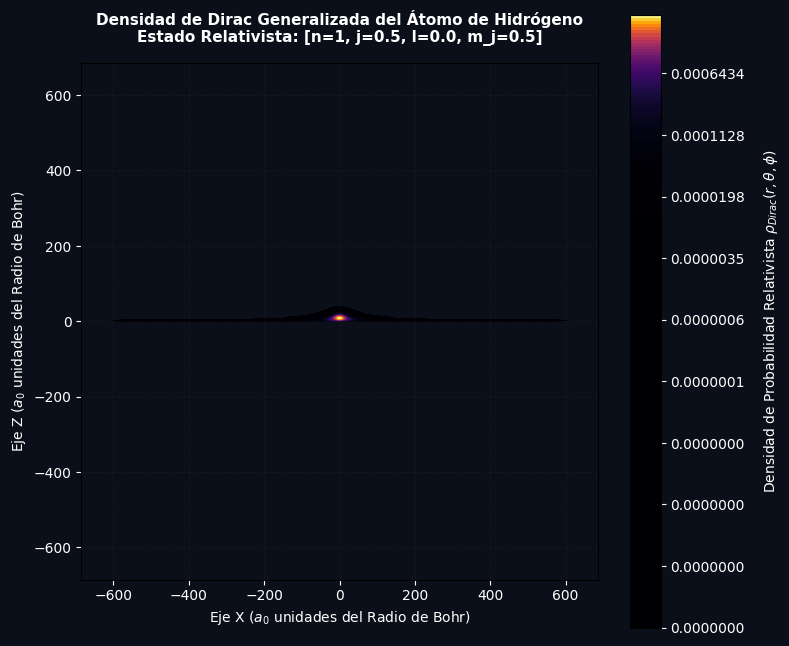

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import sph_harm, hyp1f1
from scipy.integrate import trapezoid

# =====================================================================
# 1. PARÁMETROS GENERALES Y SELECCIÓN DE ESTADO CUÁNTICO DE DIRAC
# =====================================================================
# Cambia libremente estos números cuánticos:
n = 1        # Número cuántico principal (1, 2, 3...)
j = 0.5      # Momento angular total (0.5, 1.5, 2.5 ... hasta n - 0.5)
l = j - 0.5         # Momento angular orbital (l = j - 0.5 o l = j + 0.5)
mj = 0.5     # Proyección de j (-j hasta +j en pasos de 1)

# Constantes físicas en unidades atómicas naturales (hbar = e = m_e = 1)
Z = 1               # Número atómico convertido a flotante
alpha = 1 / 137.036   # Constante de estructura fina
m = 1.0               # Masa del electrón

# Validaciones de consistencia cuántica relativista
if n < 1: raise ValueError("n debe ser mayor o igual a 1.")
if j < 0.5 or (j * 2) % 2 == 0: raise ValueError("j debe ser un semientero positivo (0.5, 1.5...).")
if j > n - 0.5: raise ValueError("j máximo permitido para n es n - 0.5.")
if l not in [int(j - 0.5), int(j + 0.5)]: raise ValueError("l debe ser igual a j - 1/2 o j + 1/2.")
if abs(mj) > j: raise ValueError("mj debe cumplir |mj| <= j.")

# Determinar el número cuántico kappa de Dirac y el número cuántico radial nr
kappa = -int(l + 1) if (j == l + 0.5) else int(l)
nr = n - int(abs(kappa))
if nr < 0: raise ValueError(f"Combinación inválida para el estado físico de Dirac (nr = {nr} < 0).")

# =====================================================================
# 2. FUNCIONES GENERALES PARA COMPONENTES RADIALES G(r) Y F(r)
# =====================================================================
def obtener_componentes_radiales(r_array, kappa, nr):
    """
    Calcula analíticamente las funciones radiales G(r) y F(r) de la ecuación
    de Dirac utilizando la función hipergeométrica confluente 1F1 de SciPy.
    Opera correctamente sobre arreglos 1D o matrices 2D.
    """
    kappa_f = float(kappa)
    gamma = np.sqrt(np.maximum(0.0, kappa_f**2 - (Z * alpha)**2))

    # Energía del estado ligado de Sommerfeld-Dirac y factor de decaimiento beta
    E = m / np.sqrt(1 + ((Z * alpha) / (nr + gamma))**2)
    beta = np.sqrt(np.maximum(0.0, m**2 - E**2))

    # Argumento de la función hipergeométrica confluente
    rho_vars = 2 * beta * r_array

    # Evaluación de las series hipergeométricas confluentes 1F1(a, b; x)
    F1 = hyp1f1(-nr, 2 * gamma + 1, rho_vars)

    if nr > 0:
        F2 = hyp1f1(-nr + 1, 2 * gamma + 1, rho_vars)
        g_coef1 = (kappa_f - (Z * alpha * m / (beta + 1e-15))) * F1 + nr * F2
        f_coef1 = (kappa_f - (Z * alpha * m / (beta + 1e-15))) * F1 - nr * F2
    else:
        g_coef1 = (kappa_f - (Z * alpha * m / (beta + 1e-15))) * F1
        f_coef1 = (kappa_f - (Z * alpha * m / (beta + 1e-15))) * F1

    # Factor de potencia asintótica común
    factor_comun = (2 * beta)**gamma * np.sqrt((beta + 1e-15) / (Z * alpha * m)) * (rho_vars**(gamma - 1)) * np.exp(-beta * r_array)

    # Amplitudes radiales base
    G = factor_comun * np.sqrt(m + E) * g_coef1
    F = factor_comun * np.sqrt(np.maximum(0.0, m - E)) * f_coef1

    return G, F, beta

# =====================================================================
# 3. CÓMPUTO GENERAL DE LOS ESPINORES ANGULARES |Omega|^2
# =====================================================================
def calcular_modulo_espinor(theta, phi):
    """
    Calcula el módulo cuadrado de los espinores armónicos esféricos acoplados
    usando coeficientes explícitos de Clebsch-Gordan para spin 1/2.
    """
    l_grande = l
    l_pequena = int(2 * j - l)

    # Componente Grande (l)
    if j == l_grande + 0.5:
        cg_up = np.sqrt((l_grande + mj + 0.5) / (2 * l_grande + 1))
        cg_down = np.sqrt((l_grande - mj + 0.5) / (2 * l_grande + 1))
    else:
        cg_up = -np.sqrt((l_grande - mj + 0.5) / (2 * l_grande + 1))
        cg_down = np.sqrt((l_grande + mj + 0.5) / (2 * l_grande + 1))

    y_up_g = sph_harm(int(mj - 0.5), l_grande, phi, theta) if abs(mj - 0.5) <= l_grande else np.zeros_like(theta)
    y_down_g = sph_harm(int(mj + 0.5), l_grande, phi, theta) if abs(mj + 0.5) <= l_grande else np.zeros_like(theta)
    ang_grande = (cg_up * np.abs(y_up_g))**2 + (cg_down * np.abs(y_down_g))**2

    # Componente Pequeña (l')
    if j == l_pequena + 0.5:
        cg_up_p = np.sqrt((l_pequena + mj + 0.5) / (2 * l_pequena + 1))
        cg_down_p = np.sqrt((l_pequena - mj + 0.5) / (2 * l_pequena + 1))
    else:
        cg_up_p = -np.sqrt((l_pequena - mj + 0.5) / (2 * l_pequena + 1))
        cg_down_p = np.sqrt((l_pequena + mj + 0.5) / (2 * l_pequena + 1))

    y_up_p = sph_harm(int(mj - 0.5), l_pequena, phi, theta) if abs(mj - 0.5) <= l_pequena else np.zeros_like(theta)
    y_down_p = sph_harm(int(mj + 0.5), l_pequena, phi, theta) if abs(mj + 0.5) <= l_pequena else np.zeros_like(theta)
    ang_pequena = (cg_up_p * np.abs(y_up_p))**2 + (cg_down_p * np.abs(y_down_p))**2

    return ang_grande, ang_pequena

# =====================================================================
# 4. REJILLA ESPACIAL 2D (PLANO XZ, Y = 0) Y EVALUACIÓN GENERAL
# =====================================================================
# Muestreo unidimensional inicial para extraer la tasa de decaimiento (beta) de forma segura
r_test = np.linspace(1e-5, 100, 2000)
_, _, beta_dinamico = obtener_componentes_radiales(r_test, kappa, nr)

# Ajuste automático del lienzo en base a la escala física del estado
limite = (n * 5) / (beta_dinamico + 1e-15)
resolucion = 400

x_vals = np.linspace(-limite, limite, resolucion)
z_vals = np.linspace(-limite, limite, resolucion)
X, Z = np.meshgrid(x_vals, z_vals)

R = np.sqrt(X**2 + Z**2)
R[R == 0] = 1e-10  # Previene divisiones por cero indeterminadas en el origen
Theta = np.arccos(Z / R)
Phi = np.zeros_like(R)

# Cómputo directo de amplitudes radiales usando la matriz 2D para evitar conflictos de dimensiones
G_mesh, F_mesh, _ = obtener_componentes_radiales(R, kappa, nr)

# Cómputo global angular
ang_g, ang_p = calcular_modulo_espinor(Theta, Phi)

# Aplicación matemática relativista exacta: rho = G^2 * |Omega_grande|^2 + F^2 * |Omega_pequeña|^2
Densidad = (G_mesh**2 * ang_g) + (F_mesh**2 * ang_p)

# Normalización numérica de la densidad final sobre el plano coordenado usando trapezoid iterativo
norm_plano = trapezoid(trapezoid(Densidad, z_vals, axis=0), x_vals)
if norm_plano > 0:
    Densidad = Densidad / norm_plano

# Limpieza analítica fina de fluctuaciones en coma flotante
Densidad = np.nan_to_num(Densidad, nan=0.0)
Densidad = np.maximum(0.0, Densidad)

# =====================================================================
# 5. GRAFICACIÓN DEL MAPA DE DENSIDAD RELATIVISTA
# =====================================================================
fig, ax = plt.subplots(figsize=(8, 7), facecolor='#0b0f19')
ax.set_facecolor('#0b0f19')

# Uso de escala logarítmica fina para capturar efectos relativistas y nodos sutiles
min_d = max(1e-10, Densidad.min())
max_d = Densidad.max()
niveles = np.logspace(np.log10(min_d + 1e-12), np.log10(max_d), 200)

mapa = ax.contourf(X, Z, Densidad, levels=niveles, cmap='inferno')

cbar = fig.colorbar(mapa, ax=ax)
cbar.set_label(r'Densidad de Probabilidad Relativista $\rho_{Dirac}(r, \theta, \phi)$', color='white', labelpad=12)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(plt.getp(cbar.ax.axes, 'yticklabels'), color='white')

# Leyenda dinámica según los números cuánticos configurados
label_estado = f"n={n}, j={j}, l={l}, m_j={mj}"
ax.set_title(f"Densidad de Dirac Generalizada del Átomo de Hidrógeno\nEstado Relativista: [{label_estado}]",
             color='white', fontsize=11, pad=15, fontweight='bold')
ax.set_xlabel(r"Eje X ($a_0$ unidades del Radio de Bohr)", color='white')
ax.set_ylabel(r"Eje Z ($a_0$ unidades del Radio de Bohr)", color='white')

ax.tick_params(colors='white')
ax.set_aspect('equal')
ax.grid(color='white', alpha=0.03, linestyle='--')

plt.tight_layout()
plt.show()

# visualización niveles de energía

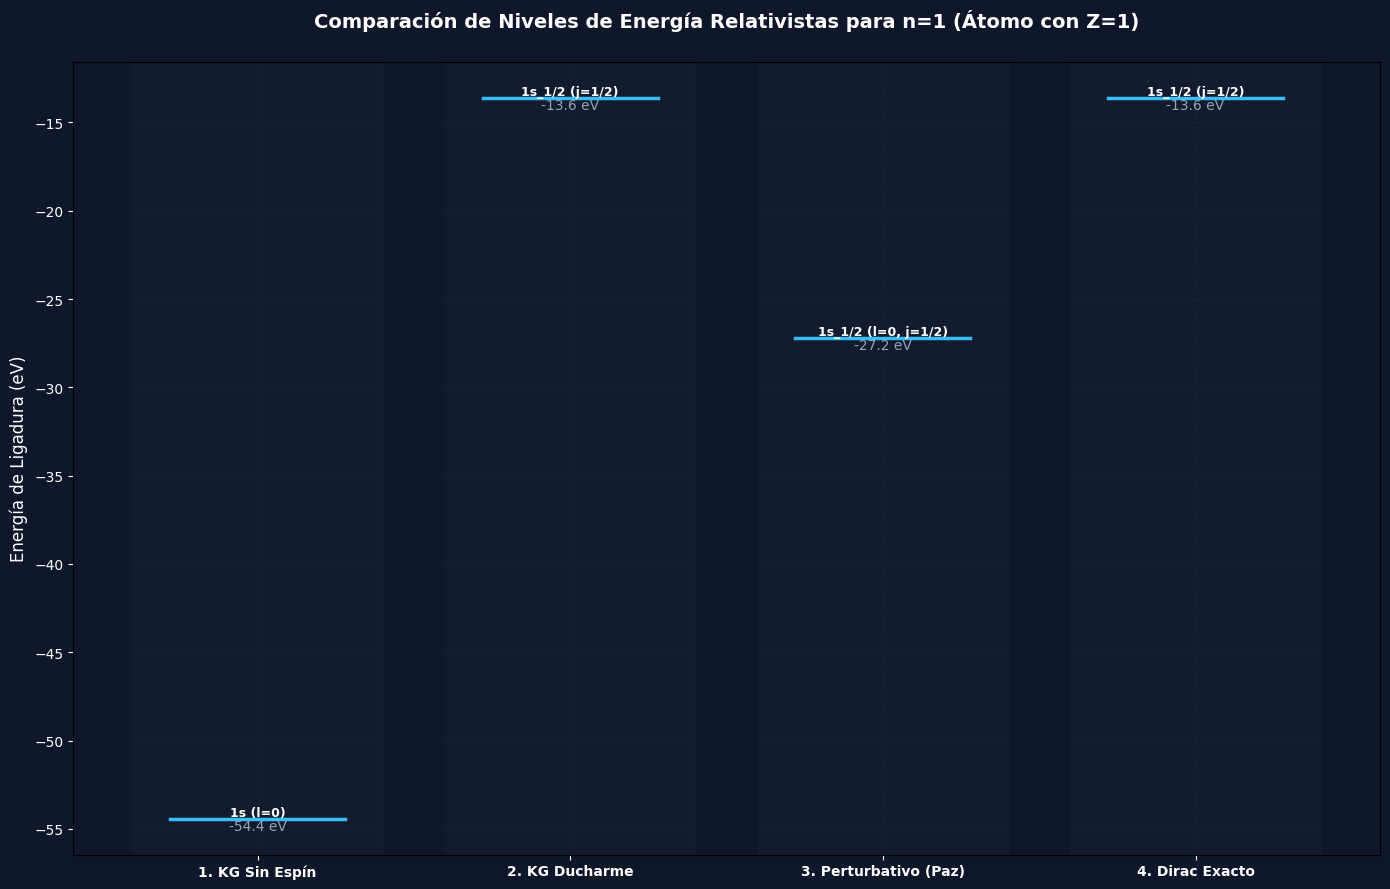


--- Valores de Energía de Ligadura Comparativos ---
Parámetros generales: Z=1, n=1
---------------------------------------------------
Método                    Estado                  Energía (eV)
---------------------------------------------------
1. KG Sin Espín           1s (l=0)                    -54.4257
2. KG Ducharme            1s_1/2 (j=1/2)              -13.6059
3. Perturbativo (Paz)     1s_1/2 (l=0, j=1/2)         -27.2114
4. Dirac Exacto           1s_1/2 (j=1/2)              -13.6059
---------------------------------------------------


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =====================================================================
# 1. PARÁMETROS FÍSICOS DEL SISTEMA
# =====================================================================
Z = 1                 # Número atómico alto para magnificar los efectos relativistas
alpha = 1 / 137.036     # Constante de estructura fina
m_e = 0.51099895e6
n = 1      # Masa del electrón en reposo (eV)

# Energía base no relativista de Bohr para n (como referencia de offset)
E_bohr_n2 = -m_e * (Z * alpha)**2 / (n * n**2)

# =====================================================================
# 2. DEFINICIÓN DE LAS ECUACIONES DE ENERGÍA
# =====================================================================

# --- 1. Klein-Gordon Estándar (Sin Espín) ---
# n_r = n - l - 1
def energia_kg_estandar(l):
    n_r = n - l - 1
    factor_raiz = np.sqrt((l + 0.5)**2 - (Z * alpha)**2)
    E_total = m_e * (1 + (Z * alpha)**2 / (n_r + factor_raiz)**2)**(-0.5)
    return E_total - m_e  # Retorna solo la energía de amarre (relativa a m_e)

# --- 2. Klein-Gordon con Corrección de Ducharme ---
# Usa la función de acoplamiento de Dirac eta_1k. Genera los mismos niveles que Dirac.
def energia_ducharme(j):
    kappa = -(j + 0.5)  # Tomamos la solución convencional kappa negativa
    gamma = np.sqrt(kappa**2 - (Z * alpha)**2)
    # N = n - j - 1/2
    N = n - j - 0.5
    eta_1kappa = 1 - gamma
    E_total = m_e * (1 + (Z * alpha)**2 / (N + 1 - eta_1kappa)**2)**(-0.5)
    return E_total - m_e

# --- 3. Klein-Gordon con Corrección de Paz (Perturbativo) ---
# Basado en los apuntes: E = E_Bohr + Delta_E_TE + Delta_E_Darwin + Delta_E_SO
def energia_paz(l, j):
    E_Bohr = -m_e * (Z * alpha)**2 / (n * n**2)

    # Término cinético relativista (TE)
    b2_l = -13/128 if l == 0 else -7/384
    E_TE = b2_l * m_e * (Z * alpha)**4

    # Término de Darwin (solo para l=0)
    E_Darwin = (8/128) * m_e * (Z * alpha)**4 if l == 0 else 0.0

    # Acoplamiento Espín-Órbita (SO)
    if l == 0:
        E_SO = 0.0
    else:
        # g = 2 para el electrón
        g = 2.0
        coef = -4*g/3 if j == 0.5 else 2*g/3
        E_SO = (coef / 128) * m_e * (Z * alpha)**4

    return E_Bohr + E_TE + E_Darwin + E_SO

# --- 4. Ecuación de Dirac Exacta (Sommerfeld-Dirac) ---
def energia_dirac(j):
    # Para 1s_1/2, j=0.5, l=0, kappa = -(l+1) = -1. Para 2p_1/2, j=0.5, l=1, kappa = l = 1
    # Usamos la definición correcta para kappa basada en j y el estado (aquí asumiendo l=j-0.5 para kappa negativo)
    if j == 0.5: # 1s_1/2 o 2p_1/2 (pero con l=0 para 1s_1/2)
      kappa = -int(j + 0.5) # Esto daría -1 para j=0.5 (como en 1s_1/2)
    else: # Otros estados como 2p_3/2
      kappa = int(j + 0.5) # Esto daría 2 para j=1.5 (como en 2p_3/2)

    gamma = np.sqrt(kappa**2 - (Z * alpha)**2)
    E_total = m_e * (1 + (Z * alpha)**2 / (n - abs(kappa) + gamma)**2)**(-0.5) # Usar abs(kappa) para el nr_dirac = n - |kappa|
    return E_total - m_e

# =====================================================================
# 3. CÁLCULO DE LOS NIVELES ESPECÍFICOS PARA n=1
# =====================================================================
niveles = {
    "1. KG Sin Espín": [
        {"label": "1s (l=0)", "E": energia_kg_estandar(l=0)}
    ],
    "2. KG Ducharme": [
        {"label": "1s_1/2 (j=1/2)", "E": energia_ducharme(j=0.5)}
    ],
    "3. Perturbativo (Paz)": [
        {"label": "1s_1/2 (l=0, j=1/2)", "E": energia_paz(l=0, j=0.5)}
    ],
    "4. Dirac Exacto": [
        {"label": "1s_1/2 (j=1/2)", "E": energia_dirac(j=0.5)}
    ]
}

# =====================================================================
# 4. PROCESO DE GRAFICADO CON MATPLOTLIB
# =====================================================================
fig, ax = plt.subplots(figsize=(14, 9), facecolor='#0f172a') # Increased figure size again
ax.set_facecolor('#0f172a')

# Configuraciones estéticas de las columnas del gráfico
columnas = list(niveles.keys())
x_coords = np.arange(len(columnas)) * 2.5
ancho_linea = 1.4

# Definir un offset vertical para el texto
text_offset_y = 0.01 # Ajusta este valor para controlar la distancia visual en eV

for idx, col in enumerate(columnas):
    x_base = x_coords[idx]

    # Dibujar fondo sutil para cada columna
    ax.axvspan(x_base - 1.0, x_base + 1.0, color='white', alpha=0.02, zorder=0)

    for estado in niveles[col]:
        E_ev = estado["E"]

        # Dibujar la línea del nivel de energía
        ax.plot([x_base - 0.7, x_base + 0.7], [E_ev, E_ev], color='#38bdf8', lw=2.5, zorder=2)

        # Agregar etiqueta de texto arriba de cada línea
        ax.text(x_base, E_ev + text_offset_y, estado["label"], color='white',
                fontsize=9, ha='center', va='bottom', weight='bold')

        # Agregar el valor numérico exacto en eV debajo de la línea
        ax.text(x_base, E_ev - text_offset_y, f"{E_ev:.1f} eV", color='#94a3b8',
                fontsize=10, ha='center', va='top')

# Configuración final de los ejes y diseño corporativo oscuro
ax.set_title(f"Comparación de Niveles de Energía Relativistas para n={n} (Átomo con Z={Z})",
             color='white', fontsize=14, pad=25, weight='bold')
ax.set_ylabel("Energía de Ligadura (eV)", color='white', fontsize=12)
ax.set_xticks(x_coords)
ax.set_xticklabels(columnas, color='white', fontsize=11, weight='bold')

ax.tick_params(colors='white', which='both', labelsize=10)
ax.grid(color='white', alpha=0.05, linestyle=':')

# Ajustar márgenes para que no se corten los textos
plt.tight_layout()
plt.show()

# =====================================================================
# 5. IMPRESIÓN DE TABLA CON LOS VALORES DE ENERGÍA
# =====================================================================
print("\n--- Valores de Energía de Ligadura Comparativos ---")
print(f"Parámetros generales: Z={Z}, n={n}")
print("---------------------------------------------------")
print(f"{'Método':<25} {'Estado':<20} {'Energía (eV)':>15}")
print("---------------------------------------------------")

for col_name, estados in niveles.items():
    for estado in estados:
        print(f"{col_name:<25} {estado['label']:<20} {estado['E']:>15.4f}")
print("---------------------------------------------------")